# 第7回: Random Forest と Gradient Boosting Machines による回帰モデル演習

## 基本情報

- 主題: Random Forest 回帰、Gradient Boosting 回帰、XGBoost、LightGBM の実装
- 作成者: 荒田禎之
- 位置づけ: 第6回の回帰分析の続き
- 使用データ: California housing dataset
- 分析課題: 住宅価格予測を題材に、tree 系アンサンブルモデルの予測性能と解釈を理解する
- 到達目標:
  - `RandomForestRegressor`, `GradientBoostingRegressor` を使える
  - `XGBRegressor`, `LGBMRegressor` を使った発展的な gradient boosting 実装を試せる
  - OOB score と permutation importance の意味を説明できる
  - learning rate、木の本数、木の深さが GBM に与える影響を確認する
  - validation data を使って hyper parameter tuning と early stopping を実行できる

This notebook includes code and explanations generated with OpenAI Codex.

---

## 1. 今回の方針

第6回では、California housing dataset を使って OLS, Ridge, LASSO を比較した。  
今回は、同じデータを使って tree 系のアンサンブルモデルを扱う。

まず扱うモデルは大きく分けて次の2つである。

| モデル | tree の作り方 | 典型的な狙い |
|---|---|---|
| Random Forest | 多数の tree を並列に作って平均する | 分散を下げる |
| Gradient Boosting | 前のモデルの失敗を補正する tree を順に足す | 関数空間での最適化 |

その後、実務でよく使われる gradient boosting 実装として XGBoost と LightGBM も試す。    
第6回と異なり、今回は人工的なノイズ変数は追加しない。  
元の California housing dataset の特徴量だけを使い、線形モデルでは難しい非線形性や相互作用を tree 系モデルがどう扱うかを見る。

---

## 2. ライブラリの読み込み


In [62]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display

from sklearn.datasets import fetch_california_housing
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.inspection import PartialDependenceDisplay, permutation_importance
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV


In [63]:
plt.style.use("ggplot")
np.random.seed(42)


---

## 3. データの読み込み

California housing dataset は、カリフォルニア州の地区ごとに、所得、築年数、部屋数、人口、緯度・経度などの情報を持ち、その地区の住宅価格中央値を予測するためのデータである。  
`as_frame=True` を指定すると、pandas の DataFrame と Series として取得できる。


In [64]:
housing = fetch_california_housing(as_frame=True)

X = housing.data.copy()
y = housing.target.copy()


In [65]:
print(type(X))
print(type(y))
print(X.shape)
print(y.shape)


<class 'pandas.core.frame.DataFrame'>
<class 'pandas.core.series.Series'>
(20640, 8)
(20640,)


先頭を確認する。


In [66]:
display(X.head())
display(y.head())


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25


,MedHouseVal
0,4.526
1,3.585
2,3.521
3,3.413
4,3.422


目的変数は住宅価格中央値であり、単位は 10 万ドルである。


In [67]:
y.describe()


,MedHouseVal
count,20640.000000
mean,2.068558
std,1.153956
min,0.149990
25%,1.196000
50%,1.797000
75%,2.647250
max,5.000010


特徴量名を確認する。


In [68]:
X.columns


Index(['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup',
       'Latitude', 'Longitude'],
      dtype='object')

今回は人工的なノイズ変数を追加しない。
使う特徴量は次の8個である。


In [69]:
feature_cols = X.columns.tolist()
feature_cols


['MedInc',
 'HouseAge',
 'AveRooms',
 'AveBedrms',
 'Population',
 'AveOccup',
 'Latitude',
 'Longitude']

---

## 4. train / test に分割する

データを学習データとテストデータに分ける。


In [70]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=42,
)

print("Train:", X_train.shape, y_train.shape)
print("Test :", X_test.shape, y_test.shape)


Train: (14448, 8) (14448,)
Test : (6192, 8) (6192,)


OLS, Ridge, LASSO では、係数の大きさや正則化の意味を揃えるために標準化が必須だった。  
一方、tree 系モデルでは閾値によって分割するので、通常は標準化をしなくても使える。

---

## 5. 評価関数を用意する

回帰モデルなので、評価指標は第5回・第6回と同じく MAE, RMSE, $R^2$ を使う。


In [71]:
def regression_metrics(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    return {"MAE": mae, "RMSE": rmse, "R2": r2}


- MAE: 予測誤差の絶対値の平均
- RMSE: 大きな誤差をより強く反映する指標
- $R^2$: 目的変数の分散をどれくらい説明できているかを表す指標

---

## 6. Random Forest を学習する

Random Forest は、次の2つのランダム化を使う。

1. 各 tree を bootstrap sample で学習する
2. 各 split で、候補にする特徴量をランダムに制限する

複数の tree の予測値を平均して、最終的な予測値とする。


In [72]:
rf = RandomForestRegressor(
    n_estimators=500,
    max_features="sqrt",
    min_samples_leaf=1,
    bootstrap=True,
    oob_score=True,
    random_state=42,
    n_jobs=-1,
)

rf.fit(X_train, y_train)


RandomForestRegressor(max_features='sqrt', n_estimators=500, n_jobs=-1,
                      oob_score=True, random_state=42)

In [73]:
y_pred_rf = rf.predict(X_test)

rf_metrics = regression_metrics(y_test, y_pred_rf)
print("OOB R2:", rf.oob_score_)
print(rf_metrics)


OOB R2: 0.8170225862125691
{'MAE': 0.3293354519702841, 'RMSE': np.float64(0.4922576609872417), 'R2': 0.8153827046060872}


`oob_score_` は OOB (out-of-bag) data を使った内部的な $R^2$ である。  
各 tree は bootstrap sample で学習されるため、ある観測を使っていない tree だけでその観測を予測できる（out-of-bag prediction）


In [74]:
result_rf = pd.DataFrame({
    "true": y_test.values,
    "pred": y_pred_rf,
})
result_rf["error"] = result_rf["pred"] - result_rf["true"]
result_rf.head()


,true,pred,error
0,0.47700,0.500646,0.023646
1,0.45800,0.907150,0.449150
2,5.00001,4.779239,-0.220771
3,2.18600,2.508522,0.322522
4,2.78000,2.339970,-0.440030


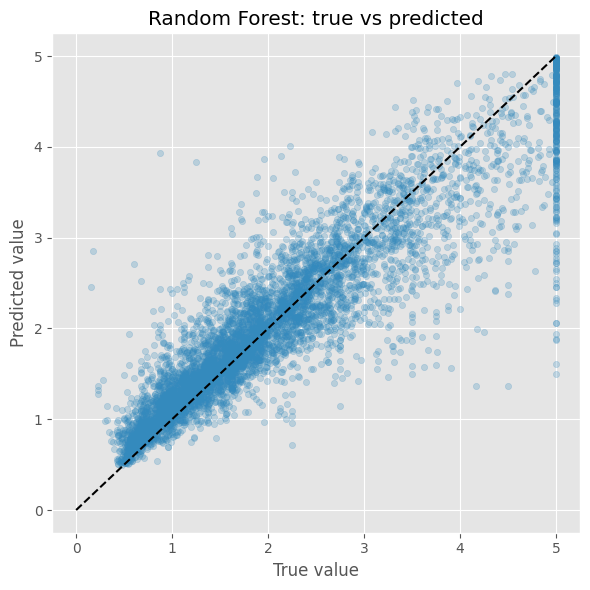

In [75]:
result_rf.plot.scatter(x="true", y="pred", alpha=0.25, figsize=(6, 6))
plt.plot([0, 5], [0, 5], color="black", linestyle="--")
plt.xlabel("True value")
plt.ylabel("Predicted value")
plt.title("Random Forest: true vs predicted")
plt.tight_layout()
plt.show()


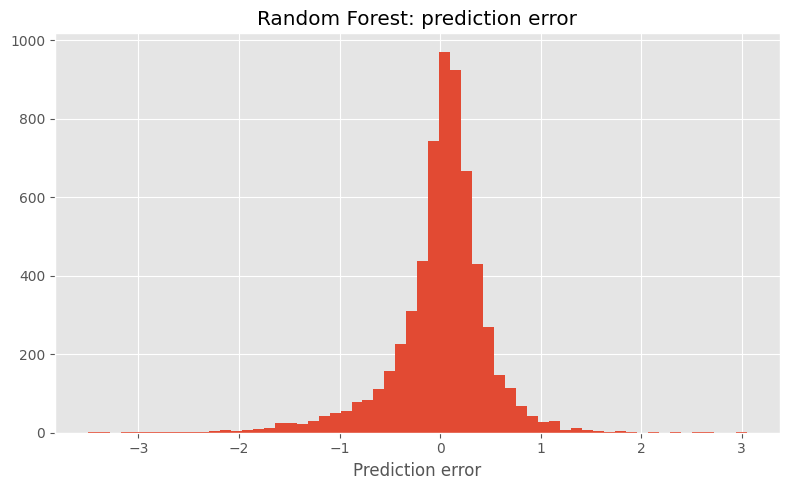

In [76]:
result_rf["error"].hist(bins=60, figsize=(8, 5))
plt.xlabel("Prediction error")
plt.title("Random Forest: prediction error")
plt.tight_layout()
plt.show()


---

## 7. OOB score と木の本数

木の本数 $B$ を増やすと、平均化が安定する。
ただし、計算時間は増える。

ここでは、木の本数を変えたときに OOB score と test score がどう変わるかを見る。


In [77]:
n_estimators_grid = [10, 30, 50, 100, 200, 400, 800]
oob_scores = []
test_scores = []

for n_estimators in n_estimators_grid:
    model = RandomForestRegressor(
        n_estimators=n_estimators,
        max_features="sqrt",
        bootstrap=True,
        oob_score=True,
        random_state=42,
        n_jobs=-1,
    )
    model.fit(X_train, y_train)
    oob_scores.append(model.oob_score_)
    test_scores.append(model.score(X_test, y_test))

score_df = pd.DataFrame({
    "n_estimators": n_estimators_grid,
    "oob_R2": oob_scores,
    "test_R2": test_scores,
})
score_df


/usr/local/lib/python3.12/dist-packages/sklearn/ensemble/_forest.py:612: UserWarning: Some inputs do not have OOB scores. This probably means too few trees were used to compute any reliable OOB estimates.
  warn(


,n_estimators,oob_R2,test_R2
0,10,0.678610,0.783778
1,30,0.786561,0.803809
2,50,0.799994,0.807625
3,100,0.807252,0.810084
4,200,0.812986,0.813678
5,400,0.816184,0.814837
6,800,0.817734,0.815920


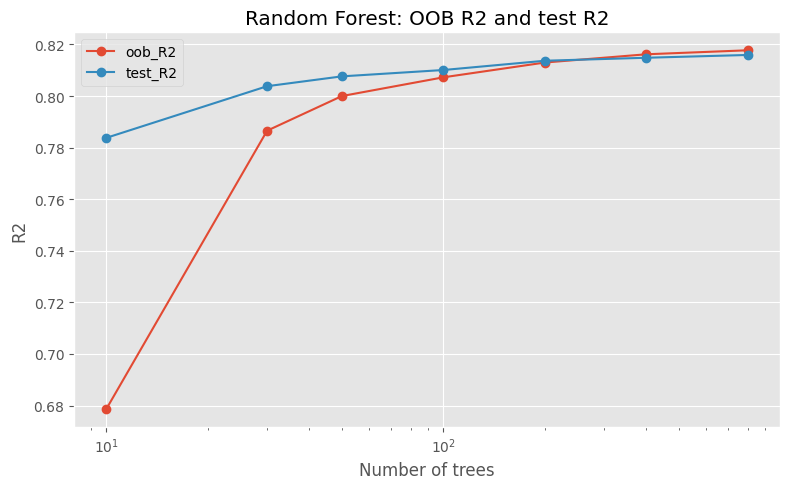

In [78]:
score_df.plot(x="n_estimators", y=["oob_R2", "test_R2"], marker="o", figsize=(8, 5))
plt.xscale("log")
plt.xlabel("Number of trees")
plt.ylabel("R2")
plt.title("Random Forest: OOB R2 and test R2")
plt.tight_layout()
plt.show()


---

## 8. `max_features` の意味

Random Forest では、各 split で候補にする特徴量数 $m$ が重要である。

- $m$ が大きいと、各 tree は強くなりやすいが、tree 同士が似やすい
- $m$ が小さいと、tree は多様になりやすいが、各 split の質が落ちることがある

scikit-learn では `max_features` で指定する。


In [79]:
max_features_grid = [1, 2, "sqrt", 0.5, 1.0]
rows = []

for max_features in max_features_grid:
    model = RandomForestRegressor(
        n_estimators=400,
        max_features=max_features,
        bootstrap=True,
        oob_score=True,
        random_state=42,
        n_jobs=-1,
    )
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    metrics = regression_metrics(y_test, y_pred)
    rows.append({
        "max_features": str(max_features),
        "oob_R2": model.oob_score_,
        **metrics,
    })

pd.DataFrame(rows)


,max_features,oob_R2,MAE,RMSE,R2
0,1,0.789001,0.369618,0.530690,0.785430
1,2,0.816184,0.329664,0.492984,0.814837
2,sqrt,0.816184,0.329664,0.492984,0.814837
3,0.5,0.816549,0.323178,0.492686,0.815061
4,1.0,0.806219,0.329275,0.502298,0.807775


この表では、予測性能だけでなく、OOB score と test score の差も見るとよい。  
OOB score は tuning の参考になるが、最終的な性能評価は test data で行う。

---

## 9. 変数重要度: impurity importance と permutation importance

Random Forest は多数の tree の集合なので、線形回帰の係数のように直接解釈することはできない。

代表的な診断方法が変数重要度である。
ここでは2種類を見る。

1. `feature_importances_`: split による不純度の減少を集計したもの
2. permutation importance: ある変数だけをシャッフルしたときの性能低下を見るもの

講義で強調したのは permutation importance である。


In [80]:
impurity_importance = pd.Series(rf.feature_importances_, index=X.columns)
impurity_importance.sort_values(ascending=False)


,0
MedInc,0.357615
Latitude,0.133768
Longitude,0.130899
AveOccup,0.122793
AveRooms,0.115021
HouseAge,0.057420
AveBedrms,0.046484
Population,0.036000


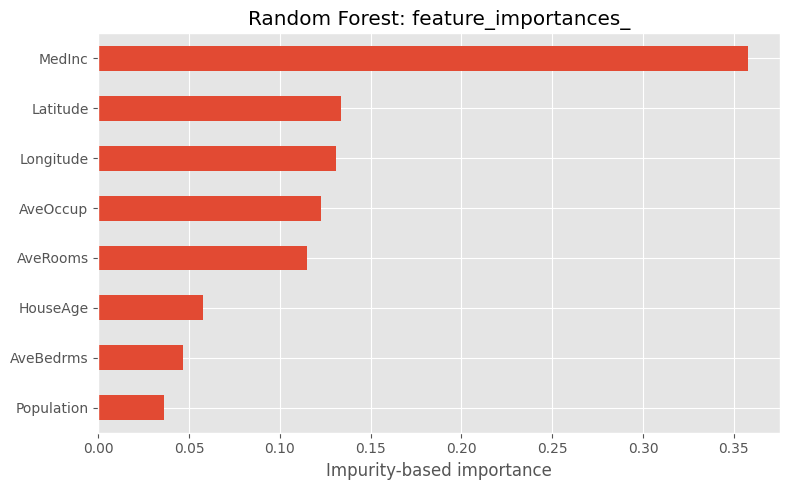

In [81]:
impurity_importance.sort_values(ascending=True).plot(kind="barh", figsize=(8, 5))
plt.xlabel("Impurity-based importance")
plt.title("Random Forest: feature_importances_")
plt.tight_layout()
plt.show()


Permutation importance では、「ある特徴量の値だけをシャッフルしたとき、予測性能がどれだけ悪化するか」を測る。  
ここでは scoring に `neg_root_mean_squared_error` を使う。  
値が大きいほど、その特徴量を壊したときに RMSE が悪化したことを意味する。


In [82]:
perm_result = permutation_importance(
    rf,
    X_test,
    y_test,
    n_repeats=20,
    random_state=42,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1,
)

perm_importance = pd.DataFrame({
    "feature": X.columns,
    "importance_mean": perm_result.importances_mean,
    "importance_std": perm_result.importances_std,
}).sort_values("importance_mean", ascending=False)

perm_importance


/usr/local/lib/python3.12/dist-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


,feature,importance_mean,importance_std
0,MedInc,0.473773,0.006822
6,Latitude,0.330846,0.005410
7,Longitude,0.279938,0.004313
5,AveOccup,0.183403,0.004457
2,AveRooms,0.072316,0.002365
1,HouseAge,0.060219,0.002365
3,AveBedrms,0.012116,0.000737
4,Population,0.006923,0.000727


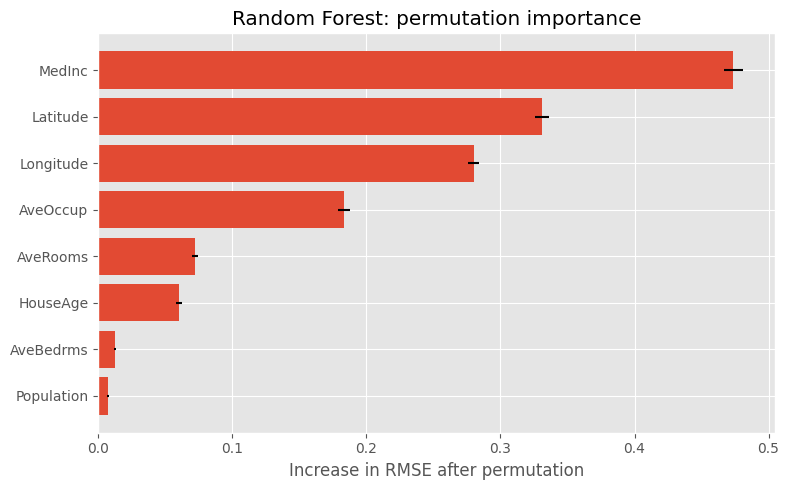

In [83]:
top_perm = perm_importance.sort_values("importance_mean")

plt.figure(figsize=(8, 5))
plt.barh(top_perm["feature"], top_perm["importance_mean"], xerr=top_perm["importance_std"])
plt.xlabel("Increase in RMSE after permutation")
plt.title("Random Forest: permutation importance")
plt.tight_layout()
plt.show()


Permutation importance は予測上の重要性であり、因果効果ではない。  
また、相関の強い変数が複数ある場合、重要度が分散したり低く見えたりすることがある。

---

## 10. scikit-learn の GradientBoostingRegressor

次に、回帰問題で `GradientBoostingRegressor` を使う。  
scikit-learn の GBM では、目的関数に明示的な tree 複雑度ペナルティを入れる正則化は行っていない（ただし、木の深さ制限などの正則化はある）。

GBM は tree を順番に追加するので、`n_estimators` と `learning_rate` の組み合わせが重要。

- `n_estimators`: 追加する tree の数の上限
- `learning_rate`: 1本の tree をどれくらい小さく足すか
- `max_depth`: 各 tree の深さの上限

小さい learning rate と多めの tree の組み合わせがよく使われる。


In [84]:
gbm = GradientBoostingRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=2,
    subsample=0.8,
    random_state=42,
)

gbm.fit(X_train, y_train)


GradientBoostingRegressor(learning_rate=0.05, max_depth=2, n_estimators=300,
                          random_state=42, subsample=0.8)

In [85]:
y_pred_gbm = gbm.predict(X_test)

gbm_metrics = regression_metrics(y_test, y_pred_gbm)
gbm_metrics


{'MAE': 0.3879476307785205,
 'RMSE': np.float64(0.5572515037235096),
 'R2': 0.7634135242394056}

In [86]:
result_gbm = pd.DataFrame({
    "true": y_test.values,
    "pred": y_pred_gbm,
})
result_gbm["error"] = result_gbm["pred"] - result_gbm["true"]
result_gbm.head()


,true,pred,error
0,0.47700,0.549595,0.072595
1,0.45800,1.156357,0.698357
2,5.00001,3.704624,-1.295386
3,2.18600,2.713667,0.527667
4,2.78000,2.287080,-0.492920


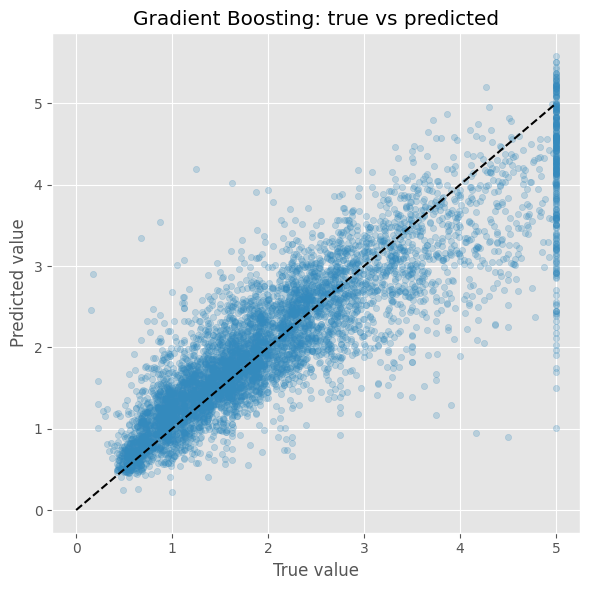

In [87]:
result_gbm.plot.scatter(x="true", y="pred", alpha=0.25, figsize=(6, 6))
plt.plot([0, 5], [0, 5], color="black", linestyle="--")
plt.xlabel("True value")
plt.ylabel("Predicted value")
plt.title("Gradient Boosting: true vs predicted")
plt.tight_layout()
plt.show()


---

## 11. `staged_predict` でステップごとの性能を見る

Boosting は tree を順番に足すため、途中段階の予測性能を見ることができる。  
`staged_predict` を使うと、1本目、2本目、...、$M$ 本目までのモデルを順に取り出せる。

ここでは、train RMSE と test RMSE を比較する。


In [88]:
train_rmse = []
test_rmse = []

for train_pred, test_pred in zip(
    gbm.staged_predict(X_train),
    gbm.staged_predict(X_test),
):
    train_rmse.append(np.sqrt(mean_squared_error(y_train, train_pred)))
    test_rmse.append(np.sqrt(mean_squared_error(y_test, test_pred)))

loss_df = pd.DataFrame({
    "iteration": np.arange(1, len(train_rmse) + 1),
    "train_RMSE": train_rmse,
    "test_RMSE": test_rmse,
})

best_iteration = int(loss_df.loc[loss_df["test_RMSE"].idxmin(), "iteration"])
best_iteration


298

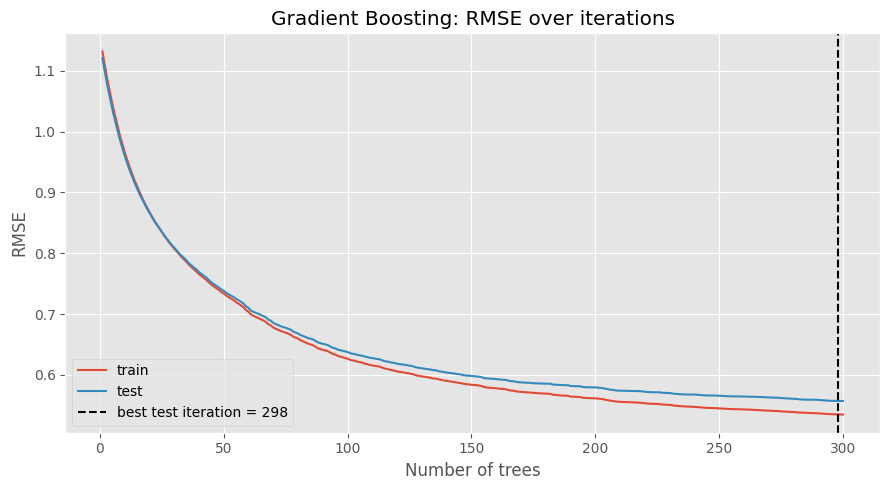

In [89]:
plt.figure(figsize=(9, 5))
plt.plot(loss_df["iteration"], loss_df["train_RMSE"], label="train")
plt.plot(loss_df["iteration"], loss_df["test_RMSE"], label="test")
plt.axvline(best_iteration, color="black", linestyle="--", label=f"best test iteration = {best_iteration}")
plt.xlabel("Number of trees")
plt.ylabel("RMSE")
plt.title("Gradient Boosting: RMSE over iterations")
plt.legend()
plt.tight_layout()
plt.show()


訓練誤差は tree を足すほど下がりやすい。
一方、テスト誤差は途中で改善が止まることがある。
この最小点付近で止める考え方が early stopping である。

---



## 13. XGBoost と LightGBM を使う

ここまで使った `GradientBoostingRegressor` は scikit-learn に含まれる基本的な GBM 実装である。  
実務では、より高速で高性能な実装として **XGBoost** や **LightGBM** がよく使われる。

XGBoost と LightGBM は scikit-learn とは別ライブラリなので、未インストールの場合は先にインストールする（Google Colab には既にインストール済なので、以下のコードは不要）


In [90]:
# 必要な場合だけ実行する
# !pip install -U xgboost lightgbm


---

### 13.1 XGBoost

XGBoost は、gradient boosted trees を高速かつ正則化付きで実装したライブラリである。  
scikit-learn と同じように、`fit` と `predict` で使える。


In [91]:
from xgboost import XGBRegressor

xgb = XGBRegressor(
    n_estimators=600,
    learning_rate=0.03,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="reg:squarederror",
    random_state=42,
    n_jobs=-1,
)

xgb.fit(X_train, y_train)


XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.8, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.03, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=4,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=600,
             n_jobs=-1, num_parallel_tree=None, ...)

In [92]:
y_pred_xgb = xgb.predict(X_test)
xgb_metrics = regression_metrics(y_test, y_pred_xgb)
xgb_metrics


{'MAE': 0.3236397145470476,
 'RMSE': np.float64(0.47690966792731543),
 'R2': 0.826715519008889}

主な hyper parameter は次の通りである。

| parameter | 意味 |
|---|---|
| `n_estimators` | tree の本数 |
| `learning_rate` | 1本の tree の寄与を小さくする係数 |
| `max_depth` | 各 tree の深さ |
| `subsample` | 各 tree を学習するときに使う観測の割合 |
| `colsample_bytree` | 各 tree を学習するときに使う特徴量の割合 |

`subsample` や `colsample_bytree` は、ランダム性を入れて過学習を抑えるために使う。

---

### 13.2 LightGBM

LightGBM も gradient boosted trees の実装である。  
大規模な表形式データで高速に動くように設計されている。


In [93]:
from lightgbm import LGBMRegressor

lgbm = LGBMRegressor(
    n_estimators=600,
    learning_rate=0.03,
    num_leaves=31,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1,
    verbose=-1,
)

lgbm.fit(X_train, y_train)


LGBMRegressor(colsample_bytree=0.8, learning_rate=0.03, n_estimators=600,
              n_jobs=-1, random_state=42, subsample=0.8, verbose=-1)

In [94]:
y_pred_lgbm = lgbm.predict(X_test)
lgbm_metrics = regression_metrics(y_test, y_pred_lgbm)
lgbm_metrics


{'MAE': 0.29324861273502056,
 'RMSE': np.float64(0.441754496389923),
 'R2': 0.8513210880803126}

`num_leaves` は tree の葉の数を制御する parameter であり、大きくすると複雑な関数を表現しやすくなるが、過学習もしやすくなる。

---

### 13.3 sklearn GBM, XGBoost, LightGBM の違い

| 実装 | 特徴 | 使いどころ |
|---|---|---|
| `GradientBoostingRegressor` | scikit-learn 標準の基本的な GBM | 理論と基本動作の理解 |
| `XGBRegressor` | 正則化や列サンプリングを含む強力な実装 | 実務・Kaggle の強い baseline |
| `LGBMRegressor` | histogram ベースで高速、大規模データに強い | 大きな表形式データでの高速な実験 |

---

## 14. GridSearchCV / RandomizedSearchCV による hyper parameter tuning





scikit-learn には hyper parameter tuning のために、次のような関数が用意されている。  
これらの関数は `XGBoost`, `LightGBM` のモデルにもそのまま使える。   
どちらも `CV` とある通り、cross-validation によって validation score を計算する。  
したがって、`X_test` は最後の評価まで使わない。

| 方法 | 内容 | 使いどころ |
|---|---|---|
| `GridSearchCV` | 指定した候補を全通り試す | 候補が少ないとき |
| `RandomizedSearchCV` | 候補からランダムに指定回数だけ試す | 候補が多いとき |

評価指標は RMSE にする。  
scikit-learn では「大きいほど良い」スコアに統一されているため、RMSE は `neg_root_mean_squared_error` として指定する。


In [95]:
scoring = "neg_root_mean_squared_error"


---

### 14.1 Random Forest: GridSearchCV

Random Forest では、たとえば次の hyper parameter を調整する。

- `n_estimators`: tree の本数
- `max_features`: 各 split で候補にする特徴量数
- `min_samples_leaf`: 葉に必要な最小サンプル数
- `max_depth`: tree の深さの上限

候補数が少ないので、まずは `GridSearchCV` で全通り試す。


In [96]:
rf_param_grid = {
    "n_estimators": [500], #[300, 500]
    "max_features": ["sqrt", 0.5],
    "min_samples_leaf": [1, 5],
    "max_depth": [None, 20],
}

rf_search = GridSearchCV(
    estimator=RandomForestRegressor(
        bootstrap=True,
        oob_score=True,
        random_state=42,
        n_jobs=-1,
    ),
    param_grid=rf_param_grid,
    scoring=scoring,
    cv=3,
    n_jobs=-1,
    verbose=1,
)

rf_search.fit(X_train, y_train)


Fitting 3 folds for each of 8 candidates, totalling 24 fits


/usr/local/lib/python3.12/dist-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


GridSearchCV(cv=3,
             estimator=RandomForestRegressor(n_jobs=-1, oob_score=True,
                                             random_state=42),
             n_jobs=-1,
             param_grid={'max_depth': [None, 20], 'max_features': ['sqrt', 0.5],
                         'min_samples_leaf': [1, 5], 'n_estimators': [500]},
             scoring='neg_root_mean_squared_error', verbose=1)

In [97]:
rf_search.best_params_


{'max_depth': None,
 'max_features': 'sqrt',
 'min_samples_leaf': 1,
 'n_estimators': 500}

In [98]:
rf_cv_results = pd.DataFrame(rf_search.cv_results_)
rf_cv_results.sort_values("rank_test_score")[[
    "rank_test_score",
    "mean_test_score",
    "std_test_score",
    "param_n_estimators",
    "param_max_features",
    "param_min_samples_leaf",
    "param_max_depth",
]].head()


,rank_test_score,mean_test_score,std_test_score,param_n_estimators,param_max_features,param_min_samples_leaf,param_max_depth
0,1,-0.507312,0.003642,500,sqrt,1,None
4,2,-0.508077,0.004022,500,sqrt,1,20
2,3,-0.511840,0.005320,500,0.5,1,None
6,4,-0.512517,0.005747,500,0.5,1,20
3,5,-0.521964,0.005807,500,0.5,5,None


`mean_test_score` は negative RMSE なので、0 に近いほど良い。  
最良モデルは `best_estimator_` に入っている。


In [99]:
rf_tuned = rf_search.best_estimator_
y_pred_rf_tuned = rf_tuned.predict(X_test)
rf_tuned_metrics = regression_metrics(y_test, y_pred_rf_tuned)

print("Best CV RMSE:", -rf_search.best_score_)
print("OOB R2:", rf_tuned.oob_score_)
rf_tuned_metrics


Best CV RMSE: 0.5073117873110796
OOB R2: 0.8170225862125691


{'MAE': 0.3293354519702841,
 'RMSE': np.float64(0.4922576609872417),
 'R2': 0.8153827046060872}

---

### 14.2 scikit-learn GBM: RandomizedSearchCV

GBM は、特に次の組み合わせが重要である。

- `learning_rate`
- `n_estimators`
- `max_depth`
- `subsample`
- `min_samples_leaf`

候補の組み合わせが増えやすいので、ここでは `RandomizedSearchCV` を使う。


In [100]:
gbm_param_distributions = {
    "n_estimators": [200, 400, 600, 800],
    "learning_rate": [0.02, 0.03, 0.05, 0.08],
    "max_depth": [1, 2, 3],
    "subsample": [0.7, 0.8, 1.0],
    "min_samples_leaf": [1, 5, 10],
}

gbm_search = RandomizedSearchCV(
    estimator=GradientBoostingRegressor(random_state=42),
    param_distributions=gbm_param_distributions,
    n_iter=12,
    scoring=scoring,
    cv=3,
    random_state=42,
    n_jobs=-1,
    verbose=1,
)

gbm_search.fit(X_train, y_train)


Fitting 3 folds for each of 12 candidates, totalling 36 fits


RandomizedSearchCV(cv=3, estimator=GradientBoostingRegressor(random_state=42),
                   n_iter=12, n_jobs=-1,
                   param_distributions={'learning_rate': [0.02, 0.03, 0.05,
                                                          0.08],
                                        'max_depth': [1, 2, 3],
                                        'min_samples_leaf': [1, 5, 10],
                                        'n_estimators': [200, 400, 600, 800],
                                        'subsample': [0.7, 0.8, 1.0]},
                   random_state=42, scoring='neg_root_mean_squared_error',
                   verbose=1)

In [101]:
gbm_search.best_params_


{'subsample': 0.7,
 'n_estimators': 600,
 'min_samples_leaf': 5,
 'max_depth': 3,
 'learning_rate': 0.08}

In [102]:
gbm_cv_results = pd.DataFrame(gbm_search.cv_results_)
gbm_cv_results.sort_values("rank_test_score")[[
    "rank_test_score",
    "mean_test_score",
    "std_test_score",
    "param_n_estimators",
    "param_learning_rate",
    "param_max_depth",
    "param_subsample",
    "param_min_samples_leaf",
]].head()


,rank_test_score,mean_test_score,std_test_score,param_n_estimators,param_learning_rate,param_max_depth,param_subsample,param_min_samples_leaf
6,1,-0.493748,0.008492,600,0.08,3,0.7,5
0,2,-0.501357,0.009854,400,0.08,3,0.8,10
4,3,-0.514165,0.006243,600,0.08,2,1.0,10
5,4,-0.519286,0.006559,800,0.05,2,1.0,5
8,5,-0.529336,0.007819,400,0.03,3,0.7,5


In [103]:
gbm_tuned = gbm_search.best_estimator_
y_pred_gbm_tuned = gbm_tuned.predict(X_test)
gbm_tuned_metrics = regression_metrics(y_test, y_pred_gbm_tuned)

print("Best CV RMSE:", -gbm_search.best_score_)
gbm_tuned_metrics


Best CV RMSE: 0.4937482238459754


{'MAE': 0.32440934090820744,
 'RMSE': np.float64(0.4770376874400017),
 'R2': 0.8266224750898228}

---

### 14.3 XGBoost: RandomizedSearchCV

XGBoost では、scikit-learn GBM の parameter に加えて、列サンプリングや正則化も調整できる。


In [104]:
xgb_param_distributions = {
    "n_estimators": [300, 600, 900],
    "learning_rate": [0.02, 0.03, 0.05, 0.08],
    "max_depth": [2, 3, 4, 5],
    "subsample": [0.7, 0.8, 1.0],
    "colsample_bytree": [0.7, 0.8, 1.0],
    "min_child_weight": [1, 5, 10],
    "reg_lambda": [1.0, 5.0, 10.0],
}

xgb_search = RandomizedSearchCV(
    estimator=XGBRegressor(
        objective="reg:squarederror",
        tree_method="hist",
        random_state=42,
        n_jobs=-1,
    ),
    param_distributions=xgb_param_distributions,
    n_iter=12,
    scoring=scoring,
    cv=3,
    random_state=42,
    n_jobs=-1,
    verbose=1,
)

xgb_search.fit(X_train, y_train)


Fitting 3 folds for each of 12 candidates, totalling 36 fits


RandomizedSearchCV(cv=3,
                   estimator=XGBRegressor(base_score=None, booster=None,
                                          callbacks=None,
                                          colsample_bylevel=None,
                                          colsample_bynode=None,
                                          colsample_bytree=None, device=None,
                                          early_stopping_rounds=None,
                                          enable_categorical=False,
                                          eval_metric=None, feature_types=None,
                                          feature_weights=None, gamma=None,
                                          grow_policy=None,
                                          importance_type=None,
                                          interaction_constraint...
                                          n_estimators=None, n_jobs=-1,
                                          num_parallel_tree=None, ...),
                   n_iter=12, n_jobs=-1,
                   param_distributions={'colsample_bytree': [0.7, 0.8, 1.0],
                                        'learning_rate': [0.02, 0.03, 0.05,
                                                          0.08],
                                        'max_depth': [2, 3, 4, 5],
                                        'min_child_weight': [1, 5, 10],
                                        'n_estimators': [300, 600, 900],
                                        'reg_lambda': [1.0, 5.0, 10.0],
                                        'subsample': [0.7, 0.8, 1.0]},
                   random_state=42, scoring='neg_root_mean_squared_error',
                   verbose=1)

In [105]:
xgb_search.best_params_


{'subsample': 0.7,
 'reg_lambda': 10.0,
 'n_estimators': 900,
 'min_child_weight': 1,
 'max_depth': 5,
 'learning_rate': 0.05,
 'colsample_bytree': 1.0}

In [106]:
xgb_tuned = xgb_search.best_estimator_
y_pred_xgb_tuned = xgb_tuned.predict(X_test)
xgb_tuned_metrics = regression_metrics(y_test, y_pred_xgb_tuned)

print("Best CV RMSE:", -xgb_search.best_score_)
xgb_tuned_metrics


Best CV RMSE: 0.46636060503164806


{'MAE': 0.2933493903421139,
 'RMSE': np.float64(0.4434216884394955),
 'R2': 0.850196734859384}

---

### 14.4 LightGBM: RandomizedSearchCV

LightGBM では、木の複雑さを表す `num_leaves` や、葉に必要なサンプル数を表す `min_child_samples` が重要である。


In [107]:
lgbm_param_distributions = {
    "n_estimators": [300, 600, 900],
    "learning_rate": [0.02, 0.03, 0.05, 0.08],
    "num_leaves": [15, 31, 63],
    "subsample": [0.7, 0.8, 1.0],
    "colsample_bytree": [0.7, 0.8, 1.0],
    "min_child_samples": [10, 20, 50],
    "reg_lambda": [0.0, 1.0, 5.0],
}

lgbm_search = RandomizedSearchCV(
    estimator=LGBMRegressor(
        random_state=42,
        n_jobs=-1,
        verbose=-1,
    ),
    param_distributions=lgbm_param_distributions,
    n_iter=12,
    scoring=scoring,
    cv=3,
    random_state=42,
    n_jobs=-1,
    verbose=1,
)

lgbm_search.fit(X_train, y_train)


Fitting 3 folds for each of 12 candidates, totalling 36 fits


RandomizedSearchCV(cv=3,
                   estimator=LGBMRegressor(n_jobs=-1, random_state=42,
                                           verbose=-1),
                   n_iter=12, n_jobs=-1,
                   param_distributions={'colsample_bytree': [0.7, 0.8, 1.0],
                                        'learning_rate': [0.02, 0.03, 0.05,
                                                          0.08],
                                        'min_child_samples': [10, 20, 50],
                                        'n_estimators': [300, 600, 900],
                                        'num_leaves': [15, 31, 63],
                                        'reg_lambda': [0.0, 1.0, 5.0],
                                        'subsample': [0.7, 0.8, 1.0]},
                   random_state=42, scoring='neg_root_mean_squared_error',
                   verbose=1)

In [108]:
lgbm_search.best_params_


{'subsample': 1.0,
 'reg_lambda': 1.0,
 'num_leaves': 63,
 'n_estimators': 900,
 'min_child_samples': 20,
 'learning_rate': 0.02,
 'colsample_bytree': 0.8}

In [109]:
lgbm_tuned = lgbm_search.best_estimator_
y_pred_lgbm_tuned = lgbm_tuned.predict(X_test)
lgbm_tuned_metrics = regression_metrics(y_test, y_pred_lgbm_tuned)

print("Best CV RMSE:", -lgbm_search.best_score_)
lgbm_tuned_metrics


Best CV RMSE: 0.45874627495274606


{'MAE': 0.2834650634727427,
 'RMSE': np.float64(0.433337821112051),
 'R2': 0.8569326254578957}

---

## 15. Early stopping

### 15.1 scikit-learn の GradientBoostingRegressor

Early stopping を使うには、`n_iter_no_change` を整数で設定する。  
`n_iter_no_change` は、ステップを繰り返した時に何回、精度の改善が見られなかったら、計算を打ち切るかという意味である。  
`validation_fraction` で指定した割合のデータが内部 validation data として取り分けられ、validation score が改善しなくなると学習が止まる。


In [110]:
gbm_es = GradientBoostingRegressor(
    n_estimators=2000,
    learning_rate=0.03,
    max_depth=2,
    subsample=0.8,
    validation_fraction=0.2,
    n_iter_no_change=20,
    tol=1e-4,
    random_state=42,
)

gbm_es.fit(X_train, y_train)


GradientBoostingRegressor(learning_rate=0.03, max_depth=2, n_estimators=2000,
                          n_iter_no_change=20, random_state=42, subsample=0.8,
                          validation_fraction=0.2)

実際に使われた tree の本数は `n_estimators_` で確認できる。


In [111]:
print("Maximum n_estimators:", 2000)
print("Actual n_estimators_:", gbm_es.n_estimators_)


Maximum n_estimators: 2000
Actual n_estimators_: 1367


In [112]:
y_pred_gbm_es = gbm_es.predict(X_test)
gbm_es_metrics = regression_metrics(y_test, y_pred_gbm_es)
gbm_es_metrics


{'MAE': 0.3578998285193791,
 'RMSE': np.float64(0.5173342211169338),
 'R2': 0.7960940814338765}

---

### 15.2 XGBoost の early stopping

XGBoost で early stopping を使うには、validation data を `eval_set` に渡し、`early_stopping_rounds` を指定する。  
`eval_set` が複数ある場合、最後のものが early stopping に使われる。

まず、`X_train` を学習用と validation 用に分ける。


In [113]:
X_train_es, X_valid_es, y_train_es, y_valid_es = train_test_split(
    X_train,
    y_train,
    test_size=0.2,
    random_state=42,
)


In [114]:
xgb_es = XGBRegressor(
    n_estimators=3000,
    learning_rate=0.03,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="reg:squarederror",
    eval_metric="rmse",
    early_stopping_rounds=50,
    random_state=42,
    n_jobs=-1,
)

xgb_es.fit(
    X_train_es,
    y_train_es,
    eval_set=[(X_valid_es, y_valid_es)],
    verbose=False,
)


XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.8, device=None, early_stopping_rounds=50,
             enable_categorical=False, eval_metric='rmse', feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.03, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=4,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=3000,
             n_jobs=-1, num_parallel_tree=None, ...)

In [115]:
print("Best iteration:", xgb_es.best_iteration)
print("Best score:", xgb_es.best_score)


Best iteration: 2096
Best score: 0.4751379510763629


In [116]:
y_pred_xgb_es = xgb_es.predict(X_test)
xgb_es_metrics = regression_metrics(y_test, y_pred_xgb_es)
xgb_es_metrics


{'MAE': 0.2991024649690534,
 'RMSE': np.float64(0.44819617990572375),
 'R2': 0.8469533887107917}

---

### 15.3 LightGBM の early stopping

LightGBM では、validation data を `eval_set` に渡し、`early_stopping()` callback を使う。


In [117]:
from lightgbm import early_stopping, log_evaluation

lgbm_es = LGBMRegressor(
    n_estimators=3000,
    learning_rate=0.03,
    num_leaves=31,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1,
    verbose=-1,
)

lgbm_es.fit(
    X_train_es,
    y_train_es,
    eval_set=[(X_valid_es, y_valid_es)],
    eval_metric="rmse",
    callbacks=[early_stopping(50), log_evaluation(0)],
)


Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[1248]	valid_0's rmse: 0.459137	valid_0's l2: 0.210807


LGBMRegressor(colsample_bytree=0.8, learning_rate=0.03, n_estimators=3000,
              n_jobs=-1, random_state=42, subsample=0.8, verbose=-1)

In [118]:
print("Best iteration:", lgbm_es.best_iteration_)
print("Best score:", lgbm_es.best_score_)


Best iteration: 1248
Best score: defaultdict(<class 'collections.OrderedDict'>, {'valid_0': OrderedDict({'rmse': np.float64(0.45913747989280945), 'l2': np.float64(0.21080722544232003)})})


In [119]:
y_pred_lgbm_es = lgbm_es.predict(X_test, num_iteration=lgbm_es.best_iteration_)
lgbm_es_metrics = regression_metrics(y_test, y_pred_lgbm_es)
lgbm_es_metrics


{'MAE': 0.28933144356868895,
 'RMSE': np.float64(0.43778253037517734),
 'R2': 0.853982714310417}

---

### 15.4 early stopping の結果を比較する


In [120]:
early_stopping_comparison = pd.DataFrame([
    {"model": "sklearn GBM early stopping", **gbm_es_metrics},
    {"model": "XGBoost early stopping", **xgb_es_metrics},
    {"model": "LightGBM early stopping", **lgbm_es_metrics},
])
early_stopping_comparison


,model,MAE,RMSE,R2
0,sklearn GBM early stopping,0.357900,0.517334,0.796094
1,XGBoost early stopping,0.299102,0.448196,0.846953
2,LightGBM early stopping,0.289331,0.437783,0.853983


`n_estimators` は、early stopping を使う場合には「最大で追加してよい木の本数」として考える。  
実際に使われる木の本数は validation data の性能によって決まる。

---

## 16. Random Forest, GBM, XGBoost, LightGBM を比較する

同じ train/test 分割で、Random Forest、scikit-learn の GBM、XGBoost、LightGBM の性能を並べる。  
いずれも tree 系モデルだが、木の作り方や正則化、計算方法は異なる。


In [121]:
comparison = pd.DataFrame([
    {
        "model": "Random Forest",
        **rf_metrics,
    },
    {
        "model": "sklearn GBM",
        **gbm_metrics,
    },
    {
        "model": "XGBoost",
        **xgb_metrics,
    },
    {
        "model": "LightGBM",
        **lgbm_metrics,
    },
    {
        "model": "RF tuned",
        **rf_tuned_metrics,
    },
    {
        "model": "GBM tuned",
        **gbm_tuned_metrics,
    },
    {
        "model": "XGBoost tuned",
        **xgb_tuned_metrics,
    },
    {
        "model": "LightGBM tuned",
        **lgbm_tuned_metrics,
    },
    {
        "model": "GBM early stopping",
        **gbm_es_metrics,
    },
    {
        "model": "XGBoost early stopping",
        **xgb_es_metrics,
    },
    {
        "model": "LightGBM early stopping",
        **lgbm_es_metrics,
    },
])
comparison


,model,MAE,RMSE,R2
0,Random Forest,0.329335,0.492258,0.815383
1,sklearn GBM,0.387948,0.557252,0.763414
2,XGBoost,0.323640,0.476910,0.826716
3,LightGBM,0.293249,0.441754,0.851321
4,RF tuned,0.329335,0.492258,0.815383
5,GBM tuned,0.324409,0.477038,0.826622
6,XGBoost tuned,0.293349,0.443422,0.850197
7,LightGBM tuned,0.283465,0.433338,0.856933
8,GBM early stopping,0.357900,0.517334,0.796094
9,XGBoost early stopping,0.299102,0.448196,0.846953


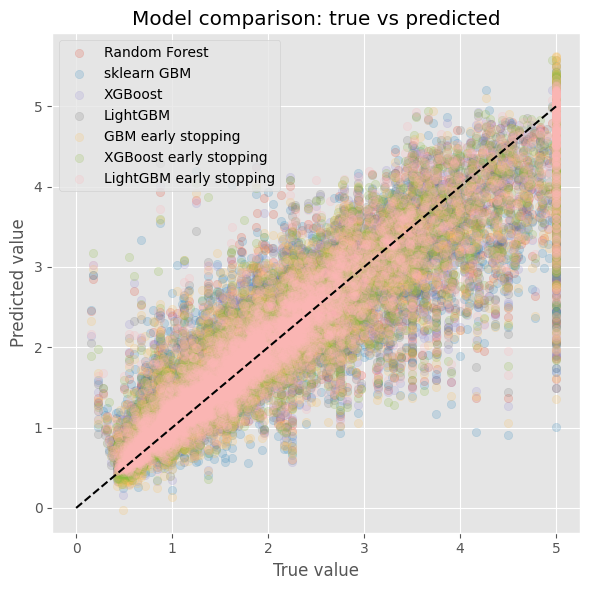

In [122]:
plt.figure(figsize=(6, 6))
plt.scatter(y_test, y_pred_rf, alpha=0.20, label="Random Forest")
plt.scatter(y_test, y_pred_gbm, alpha=0.20, label="sklearn GBM")
plt.scatter(y_test, y_pred_xgb, alpha=0.20, label="XGBoost")
plt.scatter(y_test, y_pred_lgbm, alpha=0.20, label="LightGBM")
plt.scatter(y_test, y_pred_gbm_es, alpha=0.20, label="GBM early stopping")
plt.scatter(y_test, y_pred_xgb_es, alpha=0.20, label="XGBoost early stopping")
plt.scatter(y_test, y_pred_lgbm_es, alpha=0.20, label="LightGBM early stopping")
plt.plot([0, 5], [0, 5], color="black", linestyle="--")
plt.xlabel("True value")
plt.ylabel("Predicted value")
plt.title("Model comparison: true vs predicted")
plt.legend()
plt.tight_layout()
plt.show()


重要なのは、性能の大小だけではなく、次の違いを理解することである。

| 観点 | Random Forest | sklearn GBM / XGBoost / LightGBM |
|---|---|---|
| tree の関係 | ほぼ独立に作る | 前の tree に依存して順番に作る |
| 主な発想 | 平均化で分散を下げる | 損失を下げる方向に補正を足す |
| 典型的な tree | 深めの tree | 浅めの tree を多数足す |
| 重要な調整 | `n_estimators`, `max_features`, `min_samples_leaf` | `learning_rate`, `n_estimators`, 木の複雑さ, sampling |
| 評価 | OOB score を使える | validation loss や early stopping が重要 |
